<a href="https://colab.research.google.com/github/vishalmahor886/Cat-vs-dog-classification-cnn/blob/main/cnn_cat_vs_dog_classifiaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
!kaggle datasets download -d kunalgupta2616/dog-vs-cat-images-data

Dataset URL: https://www.kaggle.com/datasets/kunalgupta2616/dog-vs-cat-images-data
License(s): GPL-2.0
100% 991M/991M [00:07<00:00, 135MB/s] 



In [4]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dog-vs-cat-images-data.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [5]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten


In [6]:
## genrators
train_data_genrator = tf.keras.utils.image_dataset_from_directory(
    directory = '/content/dogcat/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)
validation_data_genrator = tf.keras.utils.image_dataset_from_directory(
    directory = '/content/dogcat/validation',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

Found 25000 files belonging to 2 classes.
Found 8000 files belonging to 2 classes.


In [7]:
## Normalize

def process(image, label):
  image = tf.cast(image/255. ,tf.float32)
  return image, label
train_data_genrator = train_data_genrator.map(process)
validation_data_genrator = validation_data_genrator.map(process)

In [8]:
## Create CNN
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))


model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
history=model.fit(train_data_genrator, epochs=10, validation_data=validation_data_genrator)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 94ms/step - accuracy: 0.6039 - loss: 0.6634 - val_accuracy: 0.7149 - val_loss: 0.5610
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.7402 - loss: 0.5247 - val_accuracy: 0.8119 - val_loss: 0.4107
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.8338 - loss: 0.3694 - val_accuracy: 0.8876 - val_loss: 0.2843
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.9225 - loss: 0.1900 - val_accuracy: 0.9183 - val_loss: 0.2139
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 94ms/step - accuracy: 0.9668 - loss: 0.0921 - val_accuracy: 0.9371 - val_loss: 0.1729
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.9794 - loss: 0.0628 - val_accuracy: 0.9356 - val_loss: 0.1949
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 82ms/step - accuracy: 0.9880 - loss: 0.0379 - val_accuracy: 0.9596 - val_loss: 0.1388
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 93ms/step - accuracy: 0.9891 - loss: 0.0352 - 

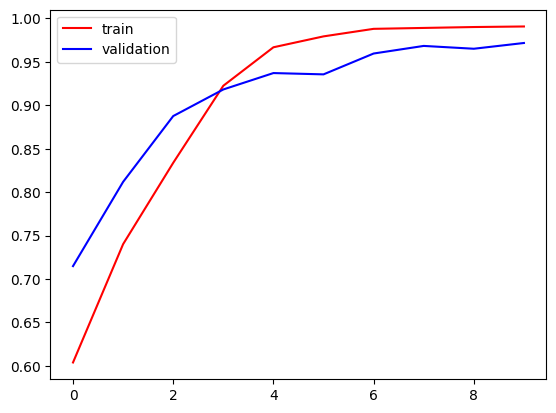

In [13]:
##plotting
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

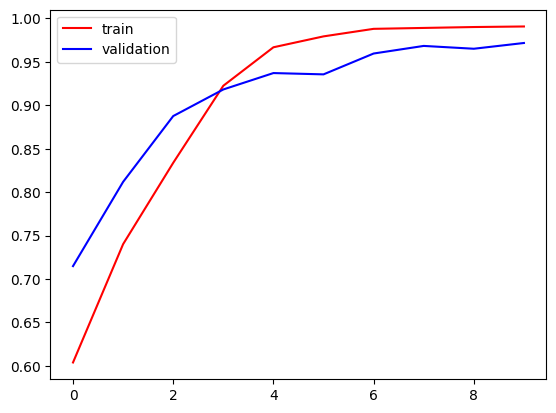

In [14]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

In [24]:
import cv2

In [30]:
test_img = cv2.imread('/content/dogcat/test1/test1/1.jpg')

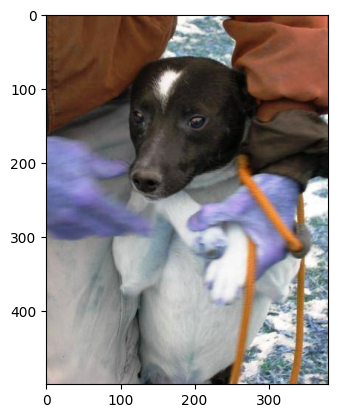

In [32]:
plt.imshow(test_img)

In [33]:
test_img.shape

(499, 381, 3)

In [34]:
test_img = cv2.resize(test_img, (256,256))

In [35]:
test_input = test_img.reshape((1,256,256,3))

In [44]:
pred = model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [46]:
if pred[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

Dog


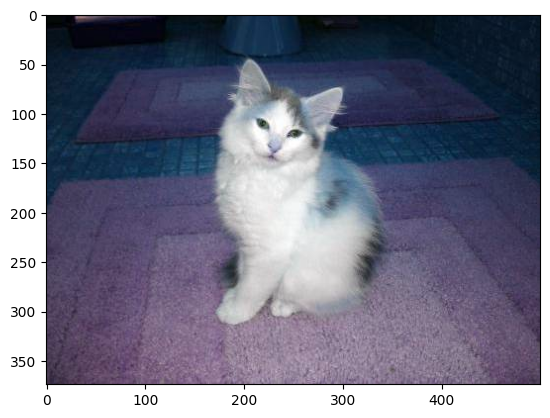

In [37]:
## for cat
test_img_cat = cv2.imread('/content/dogcat/test1/test1/10.jpg')
plt.imshow(test_img_cat)

In [38]:
test_img_cat.shape

(374, 500, 3)

In [41]:
test_img_cat = cv2.resize(test_img_cat, (256,256))
test_input_cat = test_img_cat.reshape((1,256,256,3))
pred = model.predict(test_input_cat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [47]:
if pred[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

Dog
